# Exploración

Importaciones

In [1]:
import pandas as pd

# 1. Exploración Inicial

In [2]:
df = pd.read_csv('product_activity.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


In [3]:
df.head()

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile


In [4]:
df.describe()

,user_age,votes_received,user_total_posts,days_since_signup
count,8028.000000,8782.000000,8782.000000,8782.000000
mean,27.902591,6.918356,8.324186,29.479390
std,7.547052,5.127311,6.754906,36.819928
min,16.000000,0.000000,1.000000,0.000000
25%,22.000000,3.000000,4.000000,5.000000
50%,28.000000,6.000000,6.000000,17.000000
75%,33.000000,9.000000,11.000000,40.000000
max,58.000000,74.000000,39.000000,404.000000


# Cantidad de datos nulos

In [5]:
# Contamos la cantidad de nulos, se esperan 754

total_null = df.isnull().sum()
print(total_null)

user_id                0
created_at             0
country                0
plan_type              0
user_age             754
post_id                0
post_category          0
post_created_at        0
votes_received         0
user_total_posts       0
days_since_signup      0
device_type            0
dtype: int64


# Cantidad de filas repetidas exactamente

In [6]:
# Contamos la cantidad de filas duplicadas.

duplicated_rows = df.duplicated().sum()
print(duplicated_rows)

172


In [7]:
# Controlamos que la cantidad de post_id duplicados sin que las filas sean exactas.

duplicated_post_id = df.duplicated(subset='post_id').sum()
print(duplicated_post_id)

172


# Cantidad de filas duplicadas: 
Existen 172 filas duplicadas exactas, correspondientes 1:1 con post_id repetidos → limpieza simple, sin ambigüedad

# ¿Cuántos posts ocurren antes del signup?

In [8]:
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['post_created_at'] = pd.to_datetime(df['post_created_at'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            8782 non-null   str           
 1   created_at         8781 non-null   datetime64[us]
 2   country            8782 non-null   str           
 3   plan_type          8782 non-null   str           
 4   user_age           8028 non-null   float64       
 5   post_id            8782 non-null   str           
 6   post_category      8782 non-null   str           
 7   post_created_at    8781 non-null   datetime64[us]
 8   votes_received     8782 non-null   int64         
 9   user_total_posts   8782 non-null   int64         
 10  days_since_signup  8782 non-null   int64         
 11  device_type        8782 non-null   str           
dtypes: datetime64[us](2), float64(1), int64(3), str(6)
memory usage: 823.4 KB


In [9]:
# controlamos cual es la fila que quedó como NaT razon por la que tenemos solo 8781 en las columnas created_at.

df[df['created_at'].isnull()]


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
8772,U20001,NaT,PY,pro,29.0,P0099001,tech,2025-03-01 10:00:00,4,3,1,web


1 fecha no parseable en created_at, fila con user_id=U20001, post_id=P0099001 — posible registro corrupto/de prueba

In [10]:
# controlamos cual es la fila que quedó como NaT razon por la que tenemos solo 8781 en las columnas post_created_at.

df[df['post_created_at'].isnull()]

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
8778,U20007,2025-03-15 12:00:00,MX,enterprise,38.0,P0099007,science,NaT,5,10,10,web


1 fecha no parseable en post_created_at, fila con user_id=U20007, post_id=P0099007 — posible registro corrupto/de prueba

In [11]:
df[df['post_created_at'] < df['created_at']]

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
22,U01754,2025-01-17 07:05:21,US,free,39.0,P0007502,sports,2024-12-18 16:05:21,3,6,0,web
170,U00707,2024-10-07 17:32:12,MX,pro,27.0,P0003002,gaming,2024-09-27 12:32:12,13,11,0,mobile
204,U00503,2025-01-13 13:27:33,US,FREE,16.0,P0002095,health,2024-12-14 01:27:33,7,9,0,web
208,U01763,2024-12-02 12:42:25,BR,free,39.0,P0007543,music,2024-11-08 11:42:25,5,13,0,web
288,U01122,2024-04-28 09:03:25,US,pro,22.0,P0004783,education,2024-03-29 16:03:25,11,6,0,mobile
...,...,...,...,...,...,...,...,...,...,...,...,...
8281,U00349,2025-12-28 12:28:47,BR,free,26.0,P0001541,tech,2025-12-15 20:28:47,23,1,0,web
8343,U00665,2024-11-03 04:05:20,MX,free,22.0,P0002787,music,2024-10-16 18:05:20,10,1,0,web
8608,U01378,2025-06-19 18:02:45,US,pro,26.0,P0005902,travel,2025-05-20 09:02:45,8,22,0,mobile
8646,U00243,2025-02-03 13:41:27,PY,free,35.0,P0001060,finance,2025-01-31 12:41:27,2,15,0,mobile


In [12]:
posts_antes_signup = df[df['post_created_at'] < df['created_at']]
porcentaje = (len(posts_antes_signup) / len(df)) * 100
print(porcentaje)

1.1386927806877705


# Entonces ¿cuántos post_created_at son anteriores a created_at? 100 - 1.14%

# 2. Limpieza Básica

In [13]:
df['plan_type'].value_counts()

plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64

In [14]:
df['device_type'].value_counts()

device_type
web        4416
mobile     3761
desktop     602
tablet        1
console       1
phone         1
Name: count, dtype: int64

In [15]:
df['post_category'].value_counts()

post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports           36
 science         35
sporst           35
Gaming           35
Science          34
 gaming          33
SCIENCE          33
finanse          32
FINANCE          31
EDUCATION        31
educatoin        31
Music            28
healt            28
 health          26
Education        25
GAMING           22
 education       21
Health           21
MUSIC            21
lfe              21
 music           20
Travel           20
TRAVEL           19
HEALTH           18
 travel          16
trvael           16
musc  

### Normalizamos los valores de las columnas.

In [16]:
plan_type_map = {
    'Free': 'free', 'FREE': 'free', 'FreE': 'free',
    'PRo': 'pro', 'PRO': 'pro', 'Pro': 'pro',
    'EnterPrise': 'enterprise', 'ENTERPRISE': 'enterprise', 
    'Enterprise': 'enterprise','enterprise+': 'enterprise'
}

plan_type_validos = ['free', 'pro', 'enterprise']

df['plan_type'] = df['plan_type'].str.strip()
df['plan_type'] = df['plan_type'].replace(plan_type_map)
df[~df['plan_type'].isin(plan_type_validos)]

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
8773,U20002,2025-04-10 09:15:00,BR,premium,34.0,P0099002,finance,2025-04-12 12:00:00,8,5,2,mobile
8776,U20005,2025-06-01 00:00:00,CL,vip,27.0,P0099005,mistery,2025-06-02 00:00:00,3,1,1,console


In [17]:
post_category_map = {
    'Tech': 'tech', 'TECH': 'tech', 'tehc': 'tech',
    'Life': 'life', 'LIFE': 'life', 'lfe': 'life',
    'Finance': 'finance', 'finanse': 'finance', 'FINANCE': 'finance',
    'SPORTS': 'sports', 'Sports': 'sports','sporst': 'sports', 'sp0rts': 'sports', 'sport': 'sports',
    'sciense': 'science', 'Science': 'science', 'SCIENCE': 'science',
    'Gaming': 'gaming', 'gamming': 'gaming', 'GAMING': 'gaming',
    'EDUCATION': 'education', 'educatoin': 'education', 'Education': 'education',
    'Music': 'music', 'MUSIC': 'music', 'musc': 'music',
    'healt': 'health', 'Health': 'health', 'HEALTH': 'health',
    'Travel': 'travel', 'TRAVEL': 'travel', 'trvael': 'travel',
}

post_category_validos = ['tech', 'life', 'sports', 'science', 'finance', 'gaming', 'music', 'health', 'education', 'travel']

df['post_category'] = df['post_category'].str.strip()
df['post_category'] = df['post_category'].replace(post_category_map)
df[~df['post_category'].isin(post_category_validos)]

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
8775,U20004,2024-11-20 14:30:00,AR,pro,41.0,P0099004,politics,2024-11-25 09:00:00,6,7,5,desktop
8776,U20005,2025-06-01 00:00:00,CL,vip,27.0,P0099005,mistery,2025-06-02 00:00:00,3,1,1,console


In [18]:
device_type_map = {
    'phone': 'mobile', 'tablet': 'mobile'
}

device_type_validos = ['web', 'mobile', 'desktop']

df['device_type'] = df['device_type'].str.strip()
df['device_type'] = df['device_type'].replace(device_type_map)
df[~df['device_type'].isin(device_type_validos)]

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
8776,U20005,2025-06-01,CL,vip,27.0,P0099005,mistery,2025-06-02,3,1,1,console


### Recalculo de fechas

In [19]:
df['days_since_signup_calc'] = (df['post_created_at'] - df['created_at']).dt.days
df

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type,days_since_signup_calc
0,U01988,2025-02-18 02:07:44,PY,pro,26.0,P0008515,sports,2025-05-07 20:55:28,7,16,78,mobile,78.0
1,U00236,2025-06-22 07:49:10,BR,free,27.0,P0001023,tech,2025-09-13 20:31:06,1,9,83,web,83.0
2,U00791,2024-02-12 02:45:45,CL,free,28.0,P0003405,tech,2024-02-14 05:17:48,11,2,2,mobile,2.0
3,U01522,2024-09-22 07:06:50,US,free,16.0,P0006524,finance,2024-09-24 07:51:34,5,2,2,web,2.0
4,U01092,2025-07-18 02:27:52,PY,free,NaN,P0004665,education,2025-07-24 04:56:56,7,2,6,mobile,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8777,U20006,2025-05-10 00:00:00,PY,free,30.0,P0099006,travel,2025-05-09 23:00:00,2,4,0,web,-1.0
8778,U20007,2025-03-15 12:00:00,MX,enterprise,38.0,P0099007,science,NaT,5,10,10,web,NaN
8779,U20008,2025-07-01 09:00:00,PE,pro,19.0,P0099008,sports,2025-07-02 09:00:00,7,6,1,mobile,1.0
8780,U20009,2025-08-01 10:10:10,CO,enterprise,45.0,P0099009,education,2025-08-03 10:10:10,0,2,2,desktop,2.0


In [20]:
df[df['days_since_signup_calc'] != df['days_since_signup']]

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type,days_since_signup_calc
5,U00488,2025-03-19 16:56:05,US,free,43.0,P0002030,finance,2025-03-28 12:10:25,3,10,9,web,8.0
7,U01863,2024-12-12 21:40:02,CL,free,31.0,P0008000,health,2025-02-02 21:09:32,5,5,52,mobile,51.0
9,U00880,2024-12-12 23:03:33,UY,free,32.0,P0003784,science,2024-12-19 17:52:17,7,2,7,mobile,6.0
17,U01956,2025-02-19 10:47:45,PY,free,16.0,P0008381,finance,2025-04-28 01:34:08,6,11,68,web,67.0
18,U01179,2024-08-28 23:29:24,AR,free,37.0,P0005024,education,2024-09-14 18:31:09,7,4,17,web,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8770,U00196,2025-03-04 20:50:21,US,free,35.0,P0000861,science,2025-03-06 15:03:53,5,6,2,mobile,1.0
8772,U20001,NaT,PY,pro,29.0,P0099001,tech,2025-03-01 10:00:00,4,3,1,web,NaN
8775,U20004,2024-11-20 14:30:00,AR,pro,41.0,P0099004,politics,2024-11-25 09:00:00,6,7,5,desktop,4.0
8777,U20006,2025-05-10 00:00:00,PY,free,30.0,P0099006,travel,2025-05-09 23:00:00,2,4,0,web,-1.0


In [21]:
diferencia = df['days_since_signup_calc'] - df['days_since_signup']
diferencia.describe()

count    8780.000000
mean       -0.702164
std         2.169547
min       -31.000000
25%        -1.000000
50%        -1.000000
75%         0.000000
max         3.000000
dtype: float64

In [22]:
# Controlamos la cantidad de casos que van por encima de lo normal que es de 1 dia, que se asume que es por redondeo
# pd.set_option('display.max_rows', 250)
df[diferencia.abs() > 1.0]


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type,days_since_signup_calc
22,U01754,2025-01-17 07:05:21,US,free,39.0,P0007502,sports,2024-12-18 16:05:21,3,6,0,web,-30.0
170,U00707,2024-10-07 17:32:12,MX,pro,27.0,P0003002,gaming,2024-09-27 12:32:12,13,11,0,mobile,-11.0
204,U00503,2025-01-13 13:27:33,US,free,16.0,P0002095,health,2024-12-14 01:27:33,7,9,0,web,-31.0
208,U01763,2024-12-02 12:42:25,BR,free,39.0,P0007543,music,2024-11-08 11:42:25,5,13,0,web,-25.0
223,U01293,2024-01-29 21:09:45,AR,free,32.0,P0005525,life,2024-03-09 17:57:13,6,13,43,web,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8608,U01378,2025-06-19 18:02:45,US,pro,26.0,P0005902,travel,2025-05-20 09:02:45,8,22,0,mobile,-31.0
8646,U00243,2025-02-03 13:41:27,PY,free,35.0,P0001060,finance,2025-01-31 12:41:27,2,15,0,mobile,-4.0
8656,U01731,2025-06-06 09:45:03,US,pro,NaN,P0007409,gaming,2025-06-26 21:17:09,7,12,22,mobile,20.0
8721,U00722,2024-05-11 02:00:09,BR,free,32.0,P0003074,education,2024-05-21 22:14:51,12,5,12,web,10.0


In [23]:
df[diferencia.abs() > 1.0].groupby(diferencia < 0)['days_since_signup'].describe()

,count,mean,std,min,25%,50%,75%,max
False,33.0,28.939394,31.044262,0.0,5.0,13.0,41.0,107.0
True,175.0,12.360000,25.803671,0.0,0.0,0.0,12.0,152.0


Al menos el 50% de los casos con days_since_signup_calc negativo tienen days_since_signup original = 0, lo cual es consistente con la hipótesis de que el sistema aplicaba un clamping a 0 para evitar valores negativos. El otro 50% no sigue ese patrón, sugiriendo que puede haber múltiples causas de inconsistencia en la columna original, no una sola.

### Quarantine.

In [24]:
df = df.drop_duplicates()

def calc_reason_code(fila):
    reasons =[]
    if pd.isnull(fila['created_at']) or pd.isnull(fila['post_created_at']):
        reasons.append('fecha_no_parseable')
    if pd.notnull(fila['post_created_at']) and pd.notnull(fila['created_at']) and fila['post_created_at'] < fila["created_at"]:
        reasons.append('post_<_signup')
    if fila['plan_type'] not in plan_type_validos:
        reasons.append('plan_invalido')
    if fila['device_type'] not in device_type_validos:
        reasons.append('device_invalido')
    if fila['post_category'] not in post_category_validos:
        reasons.append('category_invalida')

    return ', '.join(reasons) if reasons else None

df['reason_code'] = df.apply(calc_reason_code, axis=1)

df_quarantine = df[df['reason_code'].notnull()].copy()
df_clean = df[df['reason_code'].isnull()].copy()

In [25]:
df_clean

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type,days_since_signup_calc,reason_code
0,U01988,2025-02-18 02:07:44,PY,pro,26.0,P0008515,sports,2025-05-07 20:55:28,7,16,78,mobile,78.0,NaN
1,U00236,2025-06-22 07:49:10,BR,free,27.0,P0001023,tech,2025-09-13 20:31:06,1,9,83,web,83.0,NaN
2,U00791,2024-02-12 02:45:45,CL,free,28.0,P0003405,tech,2024-02-14 05:17:48,11,2,2,mobile,2.0,NaN
3,U01522,2024-09-22 07:06:50,US,free,16.0,P0006524,finance,2024-09-24 07:51:34,5,2,2,web,2.0,NaN
4,U01092,2025-07-18 02:27:52,PY,free,NaN,P0004665,education,2025-07-24 04:56:56,7,2,6,mobile,6.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8771,U01694,2024-02-29 05:28:40,ES,free,36.0,P0007271,life,2024-06-01 08:50:36,1,18,93,web,93.0,NaN
8774,U20003,2025-01-05 08:00:00,US,free,22.0,P0099003,health,2025-01-07 18:00:00,1,2,2,mobile,2.0,NaN
8779,U20008,2025-07-01 09:00:00,PE,pro,19.0,P0099008,sports,2025-07-02 09:00:00,7,6,1,mobile,1.0,NaN
8780,U20009,2025-08-01 10:10:10,CO,enterprise,45.0,P0099009,education,2025-08-03 10:10:10,0,2,2,desktop,2.0,NaN


## Creamos los archivos .csv de df_quarantine y df_clean

In [26]:
df_clean.to_csv('clean_product_activity.csv', index=False)
df_quarantine.to_csv('quarantine_product_activity.csv', index=False)

In [27]:
# Calculos para el Data Quality Report
print(duplicated_rows)
print(len(df)+duplicated_rows)
print(len(df))
print(len(df_clean))
print(len(df_quarantine))
print(len(df_quarantine) + len(df_clean))
print((len(df_quarantine)/len(df))*100)
posts_antes_signup = df[df['post_created_at'] < df['created_at']]
print((len(posts_antes_signup) / len(df)) * 100)

172
8782
8610
8510
100
8610
1.1614401858304297
1.1033681765389083


# Data Quality Report:

- Filas RAW                         : 8782
- Filas duplicadas                  : 172
- Valores nulos en `user_age`       : 754
- Filas luego de quitar duplicadas  : 8610
- Filas en Quarantine               : 100
- Filas CLEAN                       : 8510
- % Quarantine                      : 1.16%
- % de mismatches en fechas         : 1.10%


## 4.1 Distribuciones.

In [28]:
df_clean.groupby('plan_type')['user_id'].nunique()

plan_type
enterprise      83
free          1547
pro            367
Name: user_id, dtype: int64

In [29]:
df_clean.groupby('device_type').size()

device_type
desktop     582
mobile     3658
web        4270
dtype: int64

In [30]:
df_clean.groupby('country').size()

country
AR    1168
BR    1600
CL     552
CO     489
ES     547
MX     802
PE     393
PY     837
US    1874
UY     248
dtype: int64

In [31]:
df_clean.groupby('post_category').size()

post_category
education     682
finance       853
gaming        833
health        674
life         1034
music         673
science       870
sports       1017
tech         1382
travel        492
dtype: int64

## 4.2 Engagement

In [32]:
df_clean.groupby('plan_type')['votes_received'].describe()

,count,mean,std,min,25%,50%,75%,max
plan_type,,,,,,,,
enterprise,334.0,7.547904,4.907778,0.0,4.0,7.0,10.0,26.0
free,6569.0,6.692191,5.028869,0.0,3.0,6.0,9.0,74.0
pro,1607.0,7.654014,5.490376,0.0,4.0,7.0,10.0,50.0


In [33]:
df_clean.groupby('country')['votes_received'].describe()

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
AR,1168.0,6.771404,4.896352,0.0,3.0,6.0,9.0,48.0
BR,1600.0,6.889375,5.154609,0.0,3.0,6.0,9.0,50.0
CL,552.0,7.311594,5.055842,0.0,4.0,6.0,10.0,30.0
CO,489.0,7.308793,6.222377,0.0,3.0,6.0,10.0,74.0
ES,547.0,6.981718,4.885468,0.0,3.0,6.0,10.0,27.0
MX,802.0,6.962594,5.181702,0.0,3.0,6.0,9.0,39.0
PE,393.0,6.547074,4.995758,0.0,3.0,6.0,9.0,32.0
PY,837.0,6.600956,5.088066,0.0,3.0,6.0,9.0,62.0
US,1874.0,6.970117,5.091387,0.0,3.0,6.0,9.0,33.0


In [34]:
df_clean.groupby('post_category')['votes_received'].describe()

,count,mean,std,min,25%,50%,75%,max
post_category,,,,,,,,
education,682.0,6.781525,5.107428,0.0,3.0,6.0,9.00,43.0
finance,853.0,6.978898,5.688884,0.0,3.0,6.0,9.00,74.0
gaming,833.0,7.186074,5.472194,0.0,4.0,6.0,9.00,62.0
health,674.0,6.448071,4.567910,0.0,3.0,6.0,8.75,28.0
life,1034.0,6.173114,4.315488,0.0,3.0,5.0,8.00,31.0
music,673.0,6.286776,4.675744,0.0,3.0,5.0,9.00,32.0
science,870.0,7.544828,5.751045,0.0,4.0,6.0,10.00,48.0
sports,1017.0,6.573255,4.768746,0.0,3.0,6.0,9.00,30.0
tech,1382.0,7.688133,5.261489,0.0,4.0,7.0,10.00,38.0


In [35]:
df_clean.groupby('device_type')['votes_received'].describe()

,count,mean,std,min,25%,50%,75%,max
device_type,,,,,,,,
desktop,582.0,7.020619,4.984615,0.0,4.0,6.0,10.0,38.0
mobile,3658.0,6.827228,5.051683,0.0,3.0,6.0,9.0,62.0
web,4270.0,6.960656,5.214252,0.0,3.0,6.0,9.0,74.0


# 4.3 Promedios e Interpretación

#### Hipótesis.
La variable `posts_por_usuario_calc` será menor que `user_total_posts` porque hay post que desaparecieron en la limpieza.

In [36]:
posts_por_usuario_calc = df_clean.groupby('user_id').size()
posts_por_usuario_calc

user_id
U00001    3
U00002    4
U00003    2
U00004    3
U00005    1
         ..
U02000    9
U20003    1
U20008    1
U20009    1
U20010    1
Length: 1997, dtype: int64

In [37]:
user_total_posts_original = df_clean.groupby('user_id')['user_total_posts'].first()
user_total_posts_original

user_id
U00001    3
U00002    4
U00003    2
U00004    3
U00005    1
         ..
U02000    9
U20003    2
U20008    6
U20009    2
U20010    1
Name: user_total_posts, Length: 1997, dtype: int64

In [38]:
diferencia_posts = posts_por_usuario_calc - user_total_posts_original
diferencia_posts.describe()

count    1997.000000
mean       -0.047071
std         0.242705
min        -5.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.000000
dtype: float64

## Reporte para 4.3:

Se comparó posts_por_usuario calculado desde df_clean contra user_total_posts original. Diferencia máxima 0, mínima -5 — confirma que la limpieza (quarantine + duplicados) redujo levemente el conteo de posts de algunos usuarios, sin generar inconsistencias inesperadas.

# 4.4 Evento vs Usuario

In [39]:
promedio_por_evento = df_clean['votes_received'].mean()
promedio_por_evento

np.float64(6.9074030552291426)

In [40]:
promedio_por_usuarios = df_clean.groupby('user_id')['votes_received'].mean()
promedio_por_usuarios.mean()

np.float64(6.891317922882803)

In [41]:
df_clean['user_total_posts'].describe()

count    8510.000000
mean        8.286957
std         6.728113
min         1.000000
25%         4.000000
50%         6.000000
75%        11.000000
max        39.000000
Name: user_total_posts, dtype: float64

El promedio de votos por evento (6.91) y por usuario (6.89) son casi idénticos, lo cual indica que, en este dataset, no existe una concentración extrema de actividad en pocos usuarios que distorsione las métricas agregadas. Aunque user_total_posts muestra cierta dispersión (mediana=6, max=39), no es lo suficientemente marcada como para que el promedio por evento se aleje del promedio por usuario. Esto será evaluado con más detalle en la sección de Concentración (top 1% de usuarios).

## Concentración

In [42]:
n_top_1pct = int(len(posts_por_usuario_calc) * 0.01)
top_usuarios = posts_por_usuario_calc.sort_values(ascending=False).head(n_top_1pct)
total_posts_top1pct = top_usuarios.sum()
porcentaje = (total_posts_top1pct / len(df_clean)) * 100
print(porcentaje)

5.793184488836663


El top 1% de usuarios (19 usuarios) genera el 5.79% de los posts totales — casi 6 veces más de lo esperado bajo una distribución uniforme, confirmando una concentración moderada de actividad, consistente con lo mencionado en el enunciado del challenge

In [43]:
votos_por_usuario = df_clean.groupby('user_id')['votes_received'].sum()
top_votos = votos_por_usuario.sort_values(ascending=False).head(n_top_1pct)
total_votos_top1pct = top_votos.sum()
porcentaje_votos = (total_votos_top1pct / df_clean['votes_received'].sum()) * 100
print(porcentaje_votos)

6.17706100506958


El top 1% de usuarios concentra 5.79% de los posts y 6.17% de los votos — concentración moderada y consistente entre ambas métricas, no hay un grupo que domine desproporcionadamente un solo aspecto.

# Temporalidad

### Mensual.

In [44]:
df_clean['mes'] = df_clean['post_created_at'].dt.to_period('M')
actividad_mensual = df_clean.groupby('mes').size()
engagement_mensual = df_clean.groupby('mes')['votes_received'].mean()
actividad_mensual

mes
2024-01    195
2024-02    370
2024-03    387
2024-04    394
2024-05    456
2024-06    389
2024-07    380
2024-08    388
2024-09    304
2024-10    353
2024-11    364
2024-12    374
2025-01    399
2025-02    299
2025-03    340
2025-04    382
2025-05    354
2025-06    316
2025-07    349
2025-08    372
2025-09    373
2025-10    287
2025-11    294
2025-12    391
Freq: M, dtype: int64

In [45]:
engagement_mensual

mes
2024-01    7.056410
2024-02    7.040541
2024-03    6.627907
2024-04    6.979695
2024-05    6.800439
2024-06    6.776350
2024-07    7.134211
2024-08    6.703608
2024-09    6.677632
2024-10    7.237960
2024-11    6.552198
2024-12    6.791444
2025-01    6.827068
2025-02    7.096990
2025-03    6.823529
2025-04    6.717277
2025-05    7.251412
2025-06    6.607595
2025-07    6.719198
2025-08    7.201613
2025-09    7.198391
2025-10    7.191638
2025-11    6.942177
2025-12    6.971867
Freq: M, Name: votes_received, dtype: float64

### Semanal.

In [46]:
df_clean['semana'] = df_clean['post_created_at'].dt.to_period('W')
actividad_semanal = df_clean.groupby('semana').size()
engagement_semanal = df_clean.groupby('semana')['votes_received'].mean()
actividad_semanal

semana
2024-01-01/2024-01-07    10
2024-01-08/2024-01-14    28
2024-01-15/2024-01-21    60
2024-01-22/2024-01-28    67
2024-01-29/2024-02-04    67
                         ..
2025-12-01/2025-12-07    86
2025-12-08/2025-12-14    85
2025-12-15/2025-12-21    82
2025-12-22/2025-12-28    94
2025-12-29/2026-01-04    44
Freq: W-SUN, Length: 105, dtype: int64

In [47]:
engagement_semanal

semana
2024-01-01/2024-01-07    5.700000
2024-01-08/2024-01-14    5.892857
2024-01-15/2024-01-21    8.100000
2024-01-22/2024-01-28    7.000000
2024-01-29/2024-02-04    6.805970
                           ...   
2025-12-01/2025-12-07    6.337209
2025-12-08/2025-12-14    7.776471
2025-12-15/2025-12-21    6.682927
2025-12-22/2025-12-28    6.819149
2025-12-29/2026-01-04    7.522727
Freq: W-SUN, Name: votes_received, Length: 105, dtype: float64

## Conclusión — Temporalidad y Concentración:
La actividad mensual se mantiene relativamente estable a lo largo de todo el período analizado (entre 195 y 456 posts/mes, sin una tendencia de crecimiento o caída sostenida). La vista semanal muestra mayor variabilidad puntual —esperable al tener menos datos por período—, pero confirma el mismo patrón general de estabilidad. El engagement (votos promedio) también se mantiene consistente en ambas granularidades, oscilando siempre en un rango similar (5.7 a 8.1 en semanas, 6.5 a 7.3 en meses), sin outliers ni estacionalidad marcada.

Esto es coherente con lo observado en la sección de Concentración: el top 1% de usuarios genera un 5.79% de los posts y un 6.18% de los votos — una concentración moderada, pero no extrema. En conjunto, la evidencia sugiere una plataforma con actividad sostenida en el tiempo y sin dependencia crítica de un grupo reducido de usuarios "virales" o eventos puntuales.

# Gráficos - Concentración

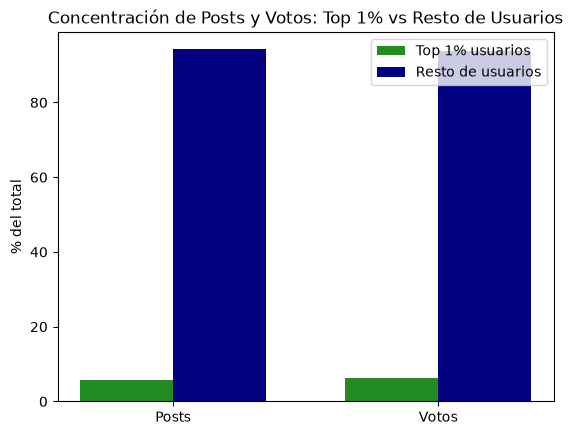

In [48]:
import matplotlib.pyplot as plt
import numpy as np

etiquetas = ['Posts', 'Votos']
top1 = [porcentaje, porcentaje_votos]
resto = [100 - porcentaje, 100 - porcentaje_votos]

x = np.arange(len(etiquetas))
ancho = 0.35

plt.bar(x - ancho/2, top1, ancho, label='Top 1% usuarios', color='forestgreen')
plt.bar(x + ancho/2, resto, ancho, label='Resto de usuarios', color='navy')

plt.xticks(x, etiquetas)
plt.ylabel('% del total')
plt.title('Concentración de Posts y Votos: Top 1% vs Resto de Usuarios')
plt.legend()
plt.show()

# Gráficos - Temporalidad

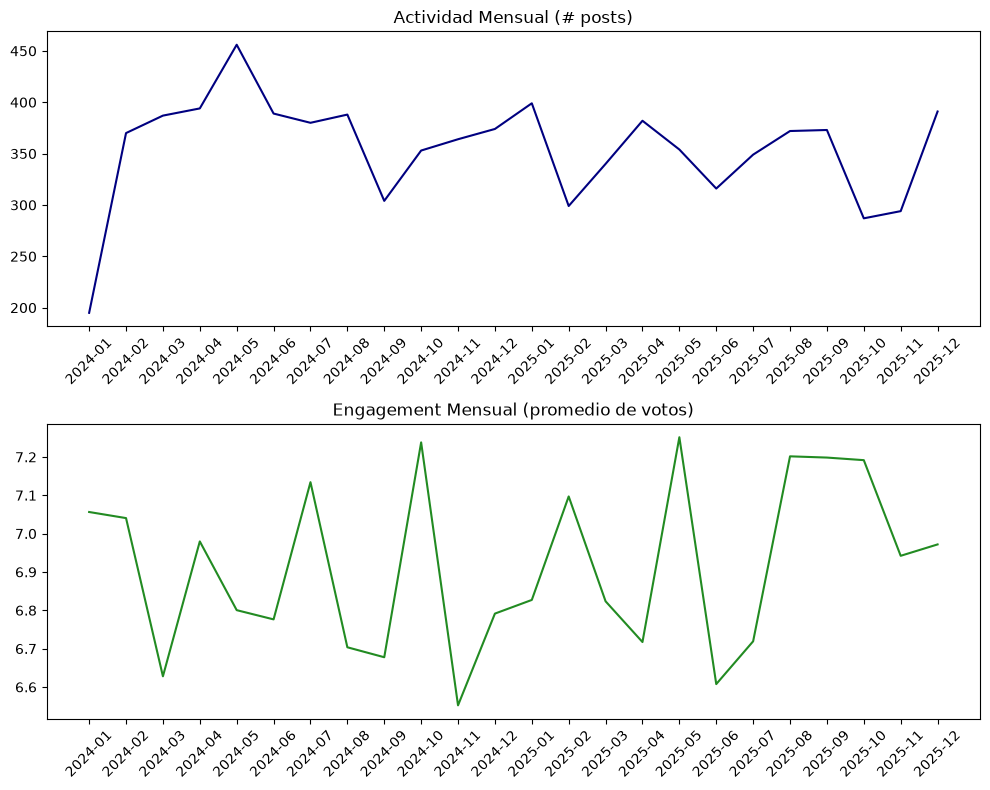

In [49]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(actividad_mensual.index.astype(str), actividad_mensual.values, color='navy')
ax1.set_title('Actividad Mensual (# posts)')
ax1.tick_params(axis='x', rotation=45)

ax2.plot(engagement_mensual.index.astype(str), engagement_mensual.values, color='forestgreen')
ax2.set_title('Engagement Mensual (promedio de votos)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Visualización de evidencia

In [51]:
df_raw = pd.read_csv('product_activity.csv')
promedio_sucio = df_raw.groupby('plan_type')['votes_received'].mean()
promedio_sucio

plan_type
 enterprise     6.571429
 free           7.096447
 pro            8.295455
ENTERPRISE      6.000000
EnterPrise      6.076923
Enterprise      7.428571
FREE            5.887755
FreE            7.021164
Free            6.120192
PRO             7.454545
PRo             7.673913
Pro             6.342857
Pro             7.421053
enterprise      7.689542
enterprise+     0.000000
free            6.714453
premium         8.000000
pro             7.745890
vip             3.000000
Name: votes_received, dtype: float64

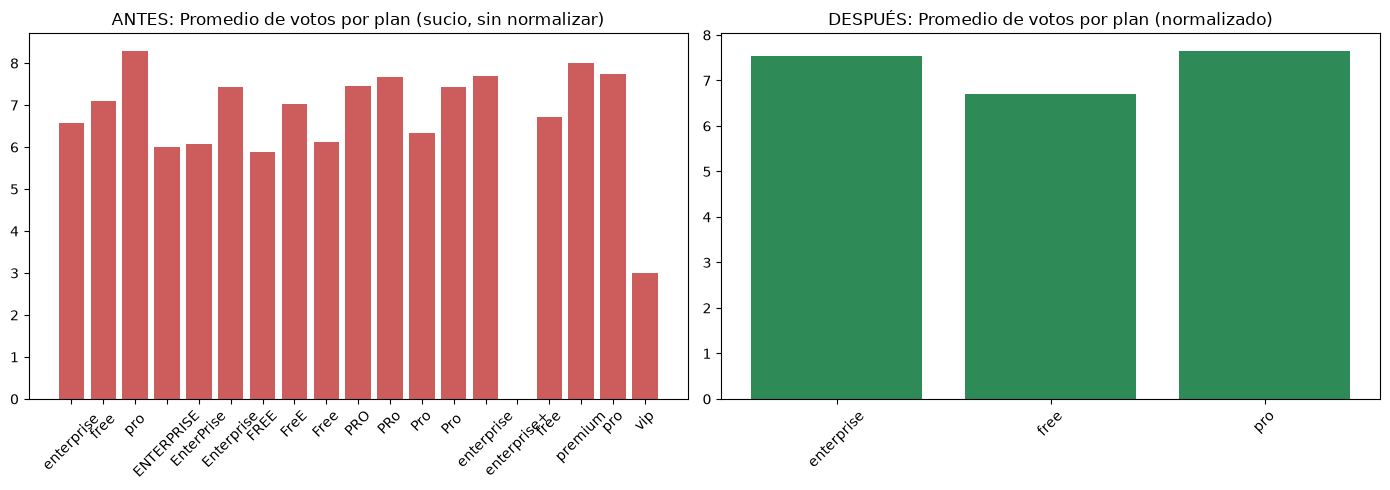

In [55]:
promedio_limpio = df_clean.groupby('plan_type')['votes_received'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(promedio_sucio.index, promedio_sucio.values, color='indianred')
ax1.set_title('ANTES: Promedio de votos por plan (sucio, sin normalizar)')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(promedio_limpio.index, promedio_limpio.values, color='seagreen')
ax2.set_title('DESPUÉS: Promedio de votos por plan (normalizado)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Product Decisions

## Preguntas

## ¿Qué segmento priorizarías y por qué?

Priorizaría el segmento enterprise. Aunque es el segmento con menos usuarios (83 de 1997, ~4.2% de la base) y un engagement promedio levemente menor al de pro (7.55 vs 7.65 votos por post), es razonable asumir — dado el modelo freemium típico de este tipo de plataformas — que enterprise representa el mayor ingreso por usuario. Con una base tan chica, tiene mayor margen relativo de crecimiento que pro (367 usuarios) o free (1547 usuarios). Limitación: el dataset no incluye una columna de precio/ingreso real, por lo que esta conclusión se basa en un supuesto razonable de la industria, no en evidencia directa.

## ¿Qué parte del tablero "mentía" antes de limpiar?

Antes de la limpieza, el tablero 'mentía' en al menos 3 formas:
1) La falta de normalización en plan_type, device_type y post_category generaba 19+ categorías fragmentadas por typos (ej: 'Free', 'FREE', 'FreE' como planes distintos) — cualquier filtro exacto de texto (ej: plan_type == 'enterprise') perdía silenciosamente usuarios que en realidad pertenecían a ese plan. Además, categorías con muy pocos casos (premium, vip, con 1 fila cada una) mostraban promedios poco confiables, que no representan ninguna tendencia real.
2) Las 172 filas duplicadas exactas inflaban artificialmente los conteos de actividad (posts) sin agregar información real.
3) La columna days_since_signup mostraba antigüedad incorrecta en varios casos (evidencia de un posible 'clamping' a 0), lo cual podría llevar a decisiones erróneas en campañas segmentadas por antigüedad de usuario (ej: tratar como 'nuevo' a alguien que no lo es).

## ¿Qué nuevo dato agregarías al tracking?

Agregaría:
1) una columna de precio/plan o ingreso por usuario, para poder priorizar segmentos con datos reales en vez de supuestos de industria.
2) un contador de votos emitidos por el usuario (no solo recibidos), para distinguir usuarios 'generadores de contenido' de 'consumidores/votantes'.
3) metadata sobre el proceso de cálculo original de days_since_signup (timestamp de cálculo, o un flag de si se aplicó algún tipo de clamping/corrección), para poder confirmar con certeza la causa de las inconsistencias detectadas en esa columna.

## Acciones

## Acción 1

In [58]:
n_top_10pct = int(len(posts_por_usuario_calc) * 0.1)
top_10pct_usuarios = posts_por_usuario_calc.sort_values(ascending=False).head(n_top_10pct)

usuarios_top10_pro = df_clean[
    (df_clean['user_id'].isin(top_10pct_usuarios.index)) & 
    (df_clean['plan_type'] == 'pro')
]['user_id'].nunique()

usuarios_top10_pro

42

Acción 1: Lanzar una campaña de upgrade dirigida a usuarios pro con alta actividad. Se identificaron 42 usuarios pro (de 367, ~11.4%) que están en el top 10% de actividad general de la plataforma (por cantidad de posts). Al ya demostrar alto compromiso, son candidatos naturales para pasar a enterprise — el segmento identificado como prioritario en 8.1 por su mayor valor potencial por usuario. Respaldo: cálculo de intersección entre top 10% de posts_por_usuario y plan_type='pro' (42 usuarios).

## Acción 2

Implementar validación de datos en el punto de entrada del sistema (ej: listas desplegables/dropdowns en vez de campos de texto libre para plan_type, device_type y post_category). Respaldo: el gráfico 'Antes/Después' de la sección de Limpieza muestra cómo la ausencia de esta validación generó 19+ categorías fragmentadas de plan_type por errores de tipeo, afectando la confiabilidad de cualquier reporte automático que dependiera de esos campos. Esta acción previene que el problema se repita a futuro, reduciendo el trabajo de limpieza manual en próximos análisis.

Exportamos el archivo `metrics_summary.csv`.

In [62]:
metrics_summary = pd.DataFrame({
    'metrica': [
        'Total posts (raw)', 'Total posts (clean)', 'Filas en quarantine',
        'Usuarios únicos', '% Quarantine', '% Mismatches fechas',
        'Promedio votos (free)', 'Promedio votos (pro)', 'Promedio votos (enterprise)',
        'Top 1% usuarios - % posts', 'Top 1% usuarios - % votos'
    ],
    'valor': [
        8782, 8510, 100,
        1997, 1.16, 1.10,
        6.69, 7.65, 7.55,
        5.79, 6.18
    ]
})

metrics_summary.to_csv('metrics_summary.csv', index=False)